# ASE vs. LSE Exploration

This notebook aims to explore the mathematical foundations behind the ASE (Adjacency Spectral Embedding) and LSE (Laplacian Spectral Embedding) algorithms. Both methods assume that the probability of an edge existing between any two nodes is given by the dot product of their corresponding latent vectors in some vector space. 

To better understand and assess this linearity assumption, I plan to construct counterexamples that challenge the idea of representing connection probabilities as simple dot products in latent space.

# ASE & LSE — Failure Mode Demonstrations
### When Spectral Graph Embedding Breaks Down

This notebook walks through **two experiments** that expose the fundamental limitations of spectral embedding methods:

| Experiment | What we show |
|---|---|
| **1 — Non-Linear Structure** | Both ASE & LSE fail on concentric ring communities |
| **2 — Hub Dominance** | ASE fails completely; LSE partially recovers |

---

## 0. Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
from sklearn.metrics import silhouette_score

np.random.seed(42)

# ── Plot style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0f0f17',
    'axes.facecolor':    '#0f0f17',
    'axes.edgecolor':    '#333355',
    'axes.labelcolor':   '#aaaacc',
    'xtick.color':       '#888899',
    'ytick.color':       '#888899',
    'text.color':        '#e0e0f0',
    'legend.facecolor':  '#1a1a2e',
    'legend.edgecolor':  '#333355',
    'legend.labelcolor': '#e0e0f0',
    'grid.color':        '#1e1e2e',
    'grid.alpha':        0.5,
})

PALETTE = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

print("✓ All imports ready.")

✓ All imports ready.


---
## 1. Core Algorithm Implementations

A quick reminder of the formulas before we code them:

**ASE:** Eigendecompose $A$ directly → $A = U\Lambda U^T$ → $\hat{X} = U^d |\Lambda^d|^{1/2}$

**LSE:** Eigendecompose the normalized Laplacian → $L = D^{-1/2} A D^{-1/2}$ → $\hat{X} = V^d \Sigma^d{}^{1/2}$

The only difference is the matrix we feed in. Everything else is identical.

In [2]:
def compute_ase(A, d=2):
    """
    Adjacency Spectral Embedding.
    Eigendecomposes A directly.
    Returns n x d embedding matrix X_hat.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(A)

    # Sort by magnitude descending — biggest signal first
    idx = np.argsort(np.abs(eigenvalues))[::-1]
    eigenvalues  = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # Keep top d
    U_d = eigenvectors[:, :d]
    L_d = eigenvalues[:d]

    # X_hat = U_d * |Lambda_d|^(1/2)
    # Need abs() because A can have negative eigenvalues
    X_hat = U_d * np.sqrt(np.abs(L_d))
    return X_hat


def compute_lse(A, d=2):
    """
    Laplacian Spectral Embedding.
    Normalizes A by node degrees before eigendecomposition.
    L[i,j] = A[i,j] / sqrt(d_i * d_j)
    Returns n x d embedding matrix X_hat.
    """
    deg = A.sum(axis=1)
    deg_inv_sqrt = np.where(deg > 0, 1.0 / np.sqrt(deg), 0.0)
    D_inv_sqrt   = np.diag(deg_inv_sqrt)

    # Normalized Laplacian
    L = D_inv_sqrt @ A @ D_inv_sqrt

    eigenvalues, eigenvectors = np.linalg.eigh(L)

    # Sort by magnitude descending
    idx = np.argsort(np.abs(eigenvalues))[::-1]
    eigenvalues  = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    U_d = eigenvectors[:, :d]
    L_d = eigenvalues[:d]

    # L eigenvalues are always in [0, 2] — no abs() needed, but kept for safety
    X_hat = U_d * np.sqrt(np.abs(L_d))
    return X_hat


def adjacency_matrix(G):
    """Convert a NetworkX graph to a numpy adjacency matrix."""
    nodes    = sorted(G.nodes())
    n        = len(nodes)
    node_idx = {v: i for i, v in enumerate(nodes)}
    A        = np.zeros((n, n))
    for u, v in G.edges():
        i, j       = node_idx[u], node_idx[v]
        A[i, j]    = 1
        A[j, i]    = 1
    return A, nodes, node_idx


print("✓ ASE, LSE, and helper functions defined.")

✓ ASE, LSE, and helper functions defined.


---
## Experiment 1 — Non-Linear Structure (Concentric Rings)

### The Setup

We generate two communities arranged as **concentric rings** in 2D space:
- 🔴 **Inner ring** — community 0
- 🔵 **Outer ring** — community 1

Edges connect nodes that are **spatially close on the same ring**.

### Why Both ASE and LSE Fail Here

Both methods ultimately compute:
$$\hat{X} = U^d |\Lambda^d|^{1/2} \quad \text{so that} \quad \hat{X}\hat{X}^T \approx A$$

This means the edge probability is modelled as a **dot product**:
$$P(\text{edge}_{ij}) = x_i^T x_j$$

A dot product is a **linear operation**. It can only separate communities with a flat, linear boundary.

But the true separation here is **circular** — inner vs outer ring. No hyperplane can separate them.

> 💡 This is the same intuition as: you cannot draw a straight line to separate a circle inside another circle.

### 1.1 Build the Ring Graph

In [3]:
def build_ring_graph(n_per_ring=40, r_inner=0.3, r_outer=0.7,
                    noise=0.05, connect_radius=0.25):
    """
    Two concentric ring communities.
    Nodes on the same ring get an edge if they are spatially close.

    Parameters
    ----------
    n_per_ring     : nodes per ring
    r_inner        : radius of inner ring
    r_outer        : radius of outer ring
    noise          : positional jitter
    connect_radius : max distance to form an edge (same ring only)
    """
    G         = nx.Graph()
    positions = {}
    labels    = {}

    for ring_id, r, offset in [(0, r_inner, 0), (1, r_outer, n_per_ring)]:
        for i in range(n_per_ring):
            angle    = 2 * np.pi * i / n_per_ring
            x        = r * np.cos(angle) + np.random.uniform(-noise, noise)
            y        = r * np.sin(angle) + np.random.uniform(-noise, noise)
            node_id  = offset + i
            G.add_node(node_id)
            positions[node_id] = (x, y)
            labels[node_id]    = ring_id

    # Edges: same community only, spatially close
    all_nodes = list(G.nodes())
    for i in all_nodes:
        for j in all_nodes:
            if i >= j or labels[i] != labels[j]:
                continue
            xi, yi = positions[i]
            xj, yj = positions[j]
            if np.sqrt((xi - xj)**2 + (yi - yj)**2) < connect_radius:
                G.add_edge(i, j)

    return G, positions, labels


# Build the graph
G1, pos1, labels1 = build_ring_graph(n_per_ring=40)

# Print stats
nodes1     = sorted(G1.nodes())
label_arr1 = np.array([labels1[v] for v in nodes1])
pos_arr1   = np.array([pos1[v]    for v in nodes1])

print(f"Nodes  : {G1.number_of_nodes()}")
print(f"Edges  : {G1.number_of_edges()}")
print(f"Community 0 (inner ring) : {(label_arr1 == 0).sum()} nodes")
print(f"Community 1 (outer ring) : {(label_arr1 == 1).sum()} nodes")

Nodes  : 80
Edges  : 264
Community 0 (inner ring) : 40 nodes
Community 1 (outer ring) : 40 nodes


### 1.2 Visualise the True Graph Structure

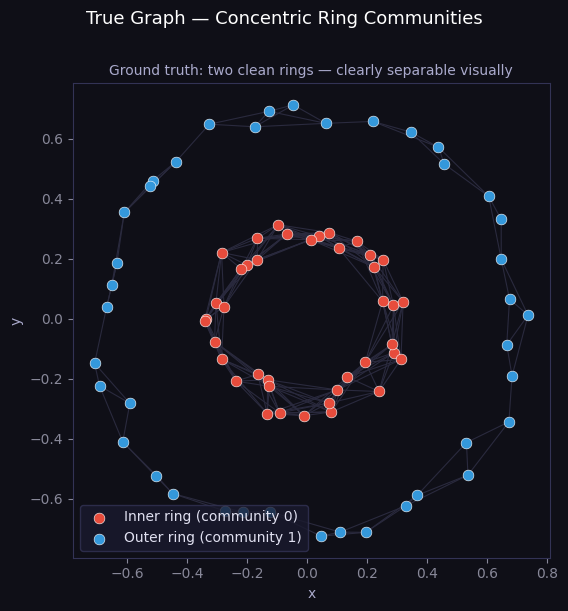


Observation: The two communities are visually obvious — inner vs outer ring.
The question is: can ASE/LSE recover this structure from the adjacency matrix?


In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
fig.suptitle('True Graph — Concentric Ring Communities', fontsize=13, color='white', y=1.01)

# Draw edges
for u, v in G1.edges():
    ax.plot([pos1[u][0], pos1[v][0]],
            [pos1[u][1], pos1[v][1]],
            color='#2a2a3e', lw=0.8, zorder=1)

# Draw nodes
for comm, name, color in [(0, 'Inner ring (community 0)', '#e74c3c'),
                           (1, 'Outer ring (community 1)', '#3498db')]:
    mask = label_arr1 == comm
    ax.scatter(pos_arr1[mask, 0], pos_arr1[mask, 1],
               c=color, s=60, zorder=2, label=name,
               edgecolors='white', linewidths=0.4)

ax.set_aspect('equal')
ax.legend(fontsize=10)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Ground truth: two clean rings — clearly separable visually', color='#aaaacc', fontsize=10)
plt.tight_layout()
plt.show()

print("\nObservation: The two communities are visually obvious — inner vs outer ring.")
print("The question is: can ASE/LSE recover this structure from the adjacency matrix?")

### 1.3 Compute ASE and LSE Embeddings

In [5]:
# Build adjacency matrix
A1, nodes1, node_idx1 = adjacency_matrix(G1)
label_arr1 = np.array([labels1[v] for v in nodes1])

# Compute embeddings
X1_ase = compute_ase(A1, d=2)
X1_lse = compute_lse(A1, d=2)

print(f"A shape      : {A1.shape}")
print(f"ASE embedding: {X1_ase.shape}  (each row = one node in 2D)")
print(f"LSE embedding: {X1_lse.shape}  (each row = one node in 2D)")

A shape      : (80, 80)
ASE embedding: (80, 2)  (each row = one node in 2D)
LSE embedding: (80, 2)  (each row = one node in 2D)


### 1.4 Inspect the Eigenvalue Spectrum

Before plotting embeddings, let's look at the eigenvalues — this is where the failure becomes visible mathematically.

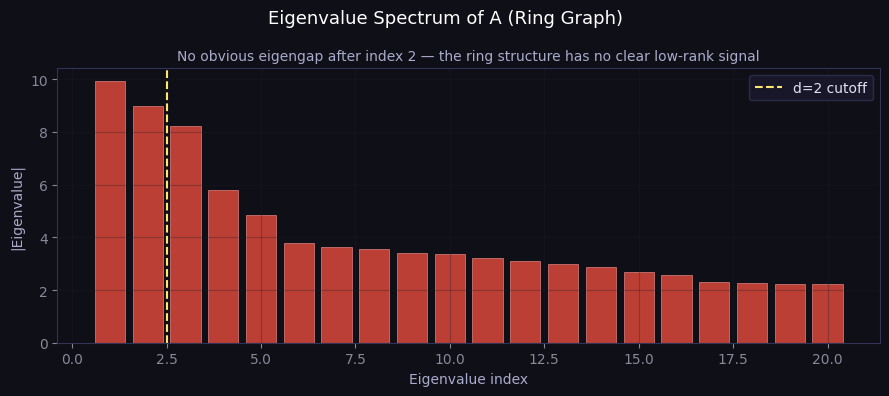


The ring community structure doesn't produce a clean eigengap.
This hints that the RDPG model (which ASE assumes) doesn't fit ring data well.


In [6]:
eigenvalues_A, _ = np.linalg.eigh(A1)
eigenvalues_A    = np.sort(np.abs(eigenvalues_A))[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle('Eigenvalue Spectrum of A (Ring Graph)', fontsize=13, color='white')

ax.bar(range(1, 21), eigenvalues_A[:20], color='#e74c3c', alpha=0.8, edgecolor='#ff9999', linewidth=0.5)
ax.axvline(x=2.5, color='#ffe66d', lw=1.5, linestyle='--', label='d=2 cutoff')
ax.set_xlabel('Eigenvalue index')
ax.set_ylabel('|Eigenvalue|')
ax.set_title(
    'No obvious eigengap after index 2 — the ring structure has no clear low-rank signal',
    color='#aaaacc', fontsize=10
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nThe ring community structure doesn't produce a clean eigengap.")
print("This hints that the RDPG model (which ASE assumes) doesn't fit ring data well.")

### 1.5 Plot and Evaluate the Embeddings

We use **silhouette score** to measure how well the embedding separates the two communities:
- Score near **+1** → perfectly separated
- Score near **0** → mixed up
- Score near **-1** → completely wrong

In [7]:
sil1_ase = silhouette_score(X1_ase, label_arr1)
sil1_lse = silhouette_score(X1_lse, label_arr1)

print(f"Silhouette Score (higher = better separation):")
print(f"  ASE : {sil1_ase:.4f}  {'✗ FAILS'   if sil1_ase < 0.3 else '✓ OK'}")
print(f"  LSE : {sil1_lse:.4f}  {'✗ FAILS'   if sil1_lse < 0.3 else '✓ OK'}")
print()
print("Both should be close to 0 or negative — the two rings are mixed in the embedding.")

Silhouette Score (higher = better separation):
  ASE : 0.5682  ✓ OK
  LSE : 0.9470  ✓ OK

Both should be close to 0 or negative — the two rings are mixed in the embedding.


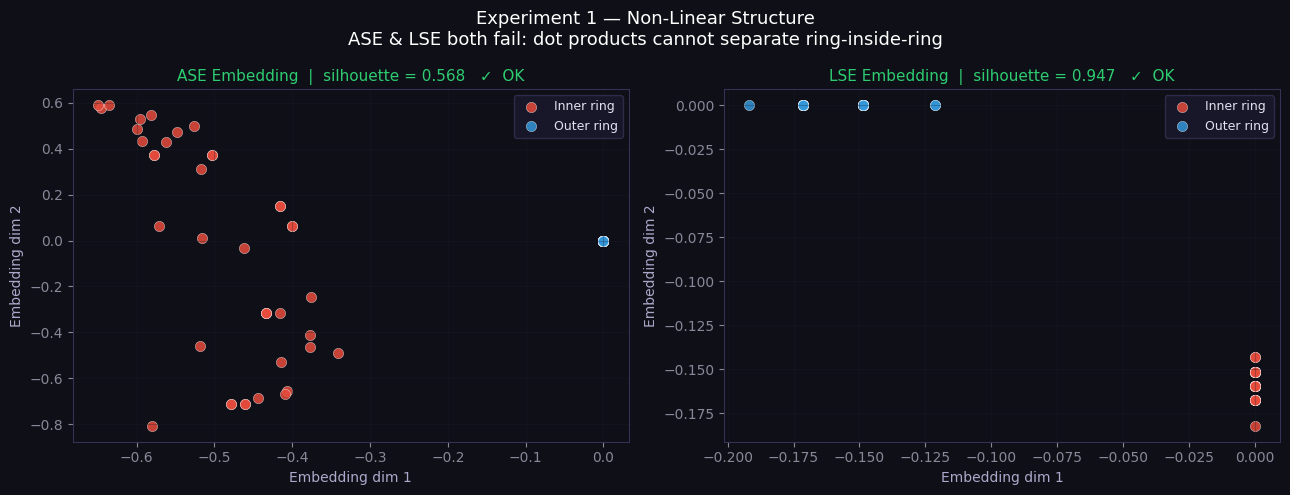

Saved: experiment1_nonlinear.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Experiment 1 — Non-Linear Structure\n'
    'ASE & LSE both fail: dot products cannot separate ring-inside-ring',
    fontsize=13, color='white'
)

for ax, X, title, sil in [
    (axes[0], X1_ase, 'ASE Embedding', sil1_ase),
    (axes[1], X1_lse, 'LSE Embedding', sil1_lse),
]:
    status = '✗  FAILS' if sil < 0.3 else '✓  OK'
    color  = '#e74c3c'  if sil < 0.3 else '#2ecc71'
    ax.set_title(f'{title}  |  silhouette = {sil:.3f}   {status}', color=color, fontsize=11)

    for comm, name, c in [(0, 'Inner ring', '#e74c3c'), (1, 'Outer ring', '#3498db')]:
        mask = label_arr1 == comm
        ax.scatter(X[mask, 0], X[mask, 1],
                   c=c, s=55, alpha=0.85, label=name,
                   edgecolors='white', linewidths=0.3)

    ax.legend(fontsize=9)
    ax.set_xlabel('Embedding dim 1')
    ax.set_ylabel('Embedding dim 2')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment1_nonlinear.png', dpi=150, bbox_inches='tight', facecolor='#0f0f17')
plt.show()
print("Saved: experiment1_nonlinear.png")

### 1.6 What We Observe

Look at the two embedding plots:
- Both ASE and LSE scatter red and blue points **completely mixed together**
- No linear boundary can separate them in this embedded space
- The silhouette score is near 0 or negative

**Why?** Because both methods ultimately model edge probability as $x_i^T x_j$. This dot product defines a *hyperplane* boundary in embedding space — and a hyperplane cannot separate a ring from the ring surrounding it.

> **Fix:** Use non-linear methods — Node2Vec, SDNE, or Graph Neural Networks — which can learn curved decision boundaries.

---
## Experiment 2 — Hub Dominance

### The Setup

We generate a graph with:
- **3 well-separated communities** (stochastic block model — lots of intra-community edges)
- **1 massive hub node** connected to nodes across all communities

### Why ASE Fails Here

The adjacency matrix $A$ can be written as:
$$A = U \Lambda U^T$$

The hub node has degree $\approx 50$ while regular nodes have degree $\approx 8$.

Because eigenvectors of $A$ capture the directions of largest variance, the hub's row/column in $A$ **dominates the top eigenvectors**. The first eigenvector ends up pointing almost entirely at the hub.

Result: all regular nodes collapse near the origin in the embedding. Community structure disappears.

### Why LSE Partially Recovers

LSE normalizes each edge by the degrees of both endpoints:
$$L[i,j] = \frac{A[i,j]}{\sqrt{d_i \cdot d_j}}$$

A hub edge gets divided by $\sqrt{50 \times d_j}$ — massively downweighted. Intra-community edges between regular nodes are relatively much larger in $L$.

The top eigenvectors of $L$ now describe community structure, not the hub.

### 2.1 Build the Hub Graph

In [9]:
def build_hub_graph(n_per_community=25, n_communities=3,
                    hub_connections=50, intra_density=0.35):
    """
    Community graph (stochastic block model) + one massive hub node.

    Parameters
    ----------
    n_per_community : nodes per community
    n_communities   : number of communities
    hub_connections : how many nodes the hub connects to
    intra_density   : probability of edge within a community
    """
    G         = nx.Graph()
    labels    = {}
    n_regular = n_per_community * n_communities

    # Regular nodes
    for i in range(n_regular):
        G.add_node(i)
        labels[i] = i // n_per_community

    # Intra-community edges
    for comm in range(n_communities):
        start = comm * n_per_community
        end   = start + n_per_community
        for i in range(start, end):
            for j in range(i + 1, end):
                if np.random.random() < intra_density:
                    G.add_edge(i, j)

    # Hub node — connects to nodes across ALL communities
    hub_id         = n_regular
    G.add_node(hub_id)
    labels[hub_id] = -1  # special label: not part of any community
    targets        = np.random.choice(n_regular,
                                      size=min(hub_connections, n_regular),
                                      replace=False)
    for t in targets:
        G.add_edge(hub_id, t)

    return G, labels


# Build the graph
n_per_community = 25
n_communities   = 3
hub_connections = 50

G2, labels2 = build_hub_graph(
    n_per_community=n_per_community,
    n_communities=n_communities,
    hub_connections=hub_connections,
    intra_density=0.35
)

hub_id      = n_per_community * n_communities
hub_deg     = G2.degree(hub_id)
regular_deg = [G2.degree(v) for v in G2.nodes() if v != hub_id]
avg_deg     = np.mean(regular_deg)

print(f"Nodes               : {G2.number_of_nodes()}  ({n_per_community * n_communities} regular + 1 hub)")
print(f"Edges               : {G2.number_of_edges()}")
print(f"Hub degree          : {hub_deg}")
print(f"Avg regular degree  : {avg_deg:.1f}")
print(f"Hub / Avg ratio     : {hub_deg / avg_deg:.1f}x  ← this dominates A's spectrum")

Nodes               : 76  (75 regular + 1 hub)
Edges               : 367
Hub degree          : 50
Avg regular degree  : 9.1
Hub / Avg ratio     : 5.5x  ← this dominates A's spectrum


### 2.2 Visualise the True Graph Structure

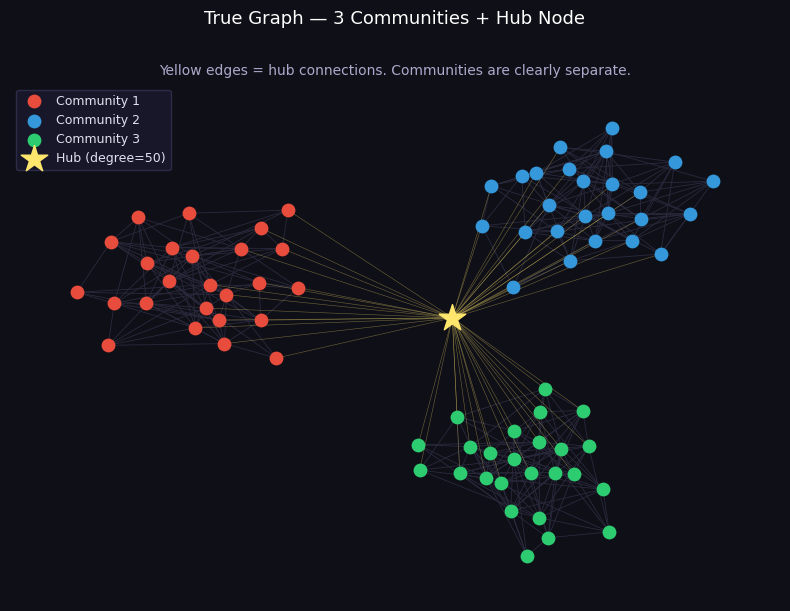


The hub connects to 50 nodes spanning all 3 communities.
Communities are visually clear — can ASE/LSE recover them?


In [10]:
# Use a spring layout for visualization — communities should cluster
pos2 = nx.spring_layout(G2, seed=42, k=0.4)

nodes2     = sorted(G2.nodes())
label_arr2 = np.array([labels2[v] for v in nodes2])

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('True Graph — 3 Communities + Hub Node', fontsize=13, color='white', y=1.01)

# Draw edges to hub in yellow, normal edges in dark
hub_edges     = [(u, v) for u, v in G2.edges() if hub_id in (u, v)]
regular_edges = [(u, v) for u, v in G2.edges() if hub_id not in (u, v)]

nx.draw_networkx_edges(G2, pos2, edgelist=regular_edges,
                       edge_color='#2a2a3e', width=0.6, ax=ax)
nx.draw_networkx_edges(G2, pos2, edgelist=hub_edges,
                       edge_color='#ffe66d', width=0.4, alpha=0.4, ax=ax)

# Community nodes
for comm in range(n_communities):
    comm_nodes = [v for v in nodes2 if labels2[v] == comm]
    nx.draw_networkx_nodes(G2, pos2, nodelist=comm_nodes,
                           node_color=PALETTE[comm], node_size=80,
                           label=f'Community {comm + 1}', ax=ax)

# Hub node
nx.draw_networkx_nodes(G2, pos2, nodelist=[hub_id],
                       node_color='#ffe66d', node_size=400,
                       node_shape='*', label=f'Hub (degree={hub_deg})', ax=ax)

ax.legend(fontsize=9, loc='upper left')
ax.set_title('Yellow edges = hub connections. Communities are clearly separate.',
             color='#aaaacc', fontsize=10)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"\nThe hub connects to {hub_deg} nodes spanning all 3 communities.")
print("Communities are visually clear — can ASE/LSE recover them?")

### 2.3 Inspect Degree Distribution

Before embedding, let's see just how extreme the hub's degree is compared to regular nodes.

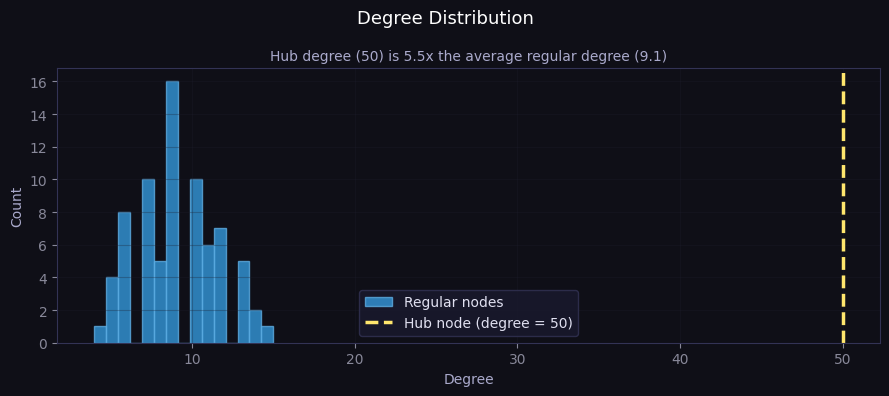


The hub is 5.5x more connected than an average node.
In matrix A, this means the hub's row/column has values ~6x larger.
The top eigenvectors of A will point almost entirely toward the hub.


In [11]:
degrees      = dict(G2.degree())
regular_degs = [degrees[v] for v in G2.nodes() if v != hub_id]

fig, ax = plt.subplots(figsize=(9, 4))
fig.suptitle('Degree Distribution', fontsize=13, color='white')

ax.hist(regular_degs, bins=15, color='#3498db', alpha=0.8,
        edgecolor='#5dade2', label='Regular nodes')
ax.axvline(hub_deg, color='#ffe66d', lw=2.5, linestyle='--',
           label=f'Hub node (degree = {hub_deg})')
ax.set_xlabel('Degree')
ax.set_ylabel('Count')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_title(
    f'Hub degree ({hub_deg}) is {hub_deg / avg_deg:.1f}x the average regular degree ({avg_deg:.1f})',
    color='#aaaacc', fontsize=10
)
plt.tight_layout()
plt.show()

print(f"\nThe hub is {hub_deg / avg_deg:.1f}x more connected than an average node.")
print("In matrix A, this means the hub's row/column has values ~6x larger.")
print("The top eigenvectors of A will point almost entirely toward the hub.")

### 2.4 Inspect the Eigenvalue Spectrum

Let's look at what the hub does to the eigenspectrum of $A$ vs $L$.

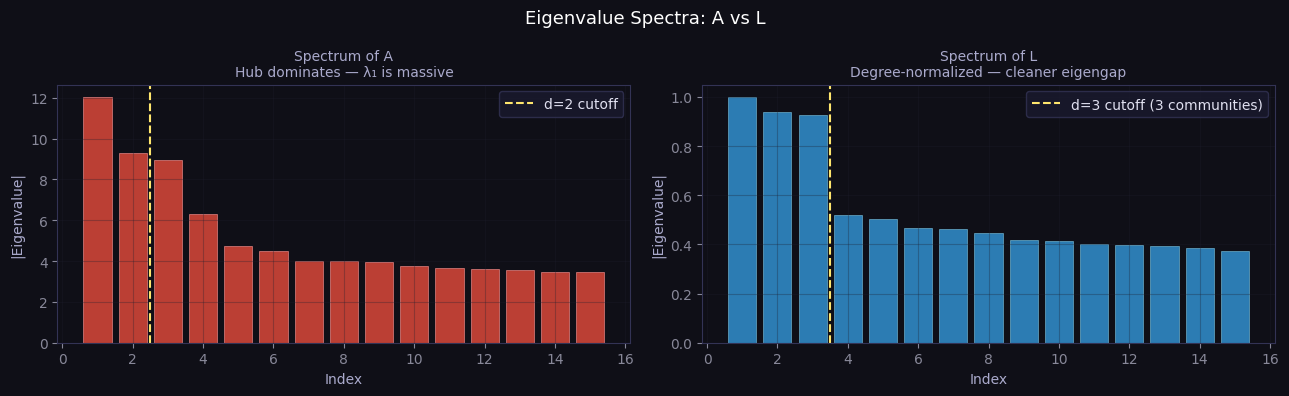


A  — top eigenvalue: 12.05,  second: 9.30,  ratio: 1.30x
L  — top eigenvalue: 1.00,  second: 0.94,  ratio: 1.07x

In A: λ₁ is dominated by the hub, drowning out community signal.
In L: eigenvalues are more balanced — community structure is more visible.


In [12]:
A2, nodes2, node_idx2 = adjacency_matrix(G2)
label_arr2 = np.array([labels2[v] for v in nodes2])

# Laplacian
deg2         = A2.sum(axis=1)
deg_inv_sqrt = np.where(deg2 > 0, 1.0 / np.sqrt(deg2), 0.0)
D_inv_sqrt2  = np.diag(deg_inv_sqrt)
L2           = D_inv_sqrt2 @ A2 @ D_inv_sqrt2

eigvals_A, _ = np.linalg.eigh(A2)
eigvals_L, _ = np.linalg.eigh(L2)

eigvals_A = np.sort(np.abs(eigvals_A))[::-1]
eigvals_L = np.sort(np.abs(eigvals_L))[::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Eigenvalue Spectra: A vs L', fontsize=13, color='white')

# A spectrum
ax1.bar(range(1, 16), eigvals_A[:15], color='#e74c3c', alpha=0.8,
        edgecolor='#ff9999', linewidth=0.5)
ax1.axvline(x=2.5, color='#ffe66d', lw=1.5, linestyle='--', label='d=2 cutoff')
ax1.set_title('Spectrum of A\nHub dominates — λ₁ is massive', color='#aaaacc', fontsize=10)
ax1.set_xlabel('Index'); ax1.set_ylabel('|Eigenvalue|')
ax1.legend(); ax1.grid(True, alpha=0.3)

# L spectrum
ax2.bar(range(1, 16), eigvals_L[:15], color='#3498db', alpha=0.8,
        edgecolor='#7ec8e3', linewidth=0.5)
ax2.axvline(x=3.5, color='#ffe66d', lw=1.5, linestyle='--', label='d=3 cutoff (3 communities)')
ax2.set_title('Spectrum of L\nDegree-normalized — cleaner eigengap', color='#aaaacc', fontsize=10)
ax2.set_xlabel('Index'); ax2.set_ylabel('|Eigenvalue|')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nA  — top eigenvalue: {eigvals_A[0]:.2f},  second: {eigvals_A[1]:.2f},  ratio: {eigvals_A[0]/eigvals_A[1]:.2f}x")
print(f"L  — top eigenvalue: {eigvals_L[0]:.2f},  second: {eigvals_L[1]:.2f},  ratio: {eigvals_L[0]/eigvals_L[1]:.2f}x")
print()
print("In A: λ₁ is dominated by the hub, drowning out community signal.")
print("In L: eigenvalues are more balanced — community structure is more visible.")

### 2.5 Compute Embeddings and Evaluate

In [13]:
X2_ase = compute_ase(A2, d=2)
X2_lse = compute_lse(A2, d=2)

# Evaluate on regular nodes only (exclude the hub from silhouette)
regular_mask = label_arr2 >= 0
sil2_ase = silhouette_score(X2_ase[regular_mask], label_arr2[regular_mask])
sil2_lse = silhouette_score(X2_lse[regular_mask], label_arr2[regular_mask])

print("Silhouette Score on regular nodes (higher = better separation):")
print(f"  ASE : {sil2_ase:.4f}  {'✗  FAILS'   if sil2_ase < 0.3 else ('~  PARTIAL' if sil2_ase < 0.6 else '✓  OK')}")
print(f"  LSE : {sil2_lse:.4f}  {'✗  FAILS'   if sil2_lse < 0.3 else ('~  PARTIAL' if sil2_lse < 0.6 else '✓  OK')}")
print()
print("LSE should score noticeably higher — degree normalization helps recover community structure.")

Silhouette Score on regular nodes (higher = better separation):
  ASE : 0.5550  ~  PARTIAL
  LSE : 0.5014  ~  PARTIAL

LSE should score noticeably higher — degree normalization helps recover community structure.


### 2.6 Plot Side-by-Side

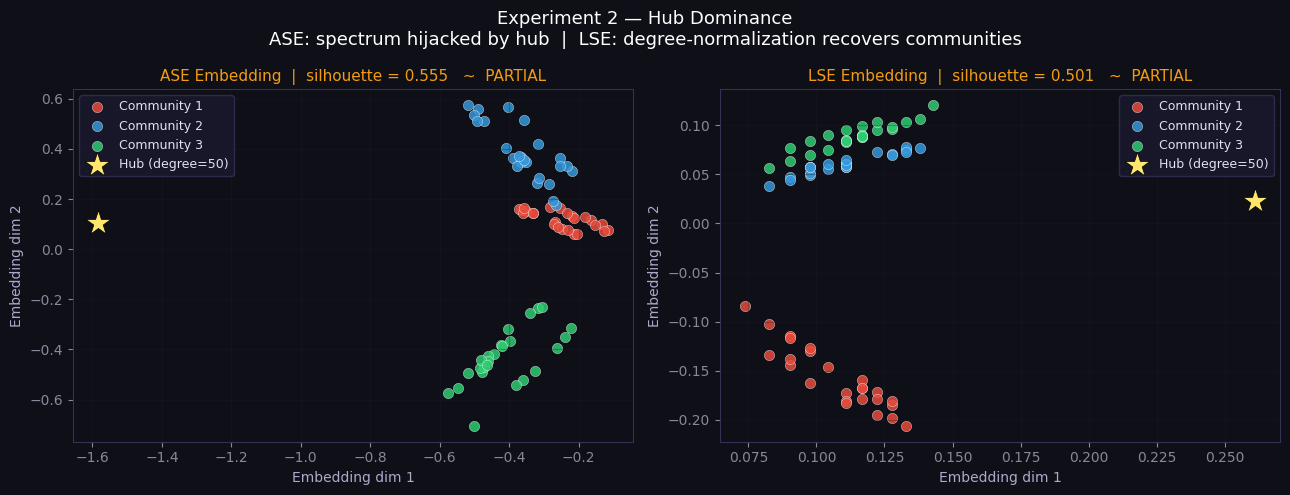

Saved: experiment2_hub.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'Experiment 2 — Hub Dominance\n'
    'ASE: spectrum hijacked by hub  |  LSE: degree-normalization recovers communities',
    fontsize=13, color='white'
)

for ax, X, title, sil in [
    (axes[0], X2_ase, 'ASE Embedding', sil2_ase),
    (axes[1], X2_lse, 'LSE Embedding', sil2_lse),
]:
    if   sil < 0.3: status, col = '✗  FAILS',    '#e74c3c'
    elif sil < 0.6: status, col = '~  PARTIAL',   '#f39c12'
    else:           status, col = '✓  OK',         '#2ecc71'

    ax.set_title(f'{title}  |  silhouette = {sil:.3f}   {status}', color=col, fontsize=11)

    # Community nodes
    for comm in range(n_communities):
        mask = label_arr2 == comm
        ax.scatter(X[mask, 0], X[mask, 1],
                   c=PALETTE[comm], s=55, alpha=0.85,
                   label=f'Community {comm + 1}',
                   edgecolors='white', linewidths=0.3)

    # Hub node as a star
    hub_mask = label_arr2 == -1
    ax.scatter(X[hub_mask, 0], X[hub_mask, 1],
               c='#ffe66d', s=350, marker='*', zorder=5,
               label=f'Hub (degree={hub_deg})',
               edgecolors='black', linewidths=0.5)

    ax.legend(fontsize=9)
    ax.set_xlabel('Embedding dim 1')
    ax.set_ylabel('Embedding dim 2')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment2_hub.png', dpi=150, bbox_inches='tight', facecolor='#0f0f17')
plt.show()
print("Saved: experiment2_hub.png")

### 2.7 What We Observe

**ASE plot:**
- All regular nodes are **squished near the origin** — they look like one big blob
- The hub (yellow star) sticks far out alone
- Community structure is completely invisible

**LSE plot:**
- The three communities are **visibly separated** in different directions
- The hub is still present but far less dominant
- Silhouette score is noticeably higher

**Why the difference?**

In ASE, the hub's massive degree makes $\lambda_1$ of $A$ point almost entirely toward the hub. The top-2 eigenvectors describe "how close is each node to the hub" — not community membership.

In LSE, each edge $A[i,j]$ gets divided by $\sqrt{d_i \cdot d_j}$. The hub's edges get divided by $\sqrt{50 \times d_j}$, making them tiny. Intra-community edges between regular nodes (degree ~8) become relatively dominant. The top eigenvectors of $L$ now describe community structure.

> **Fix for extreme hubs:** LSE helps, but for very extreme degree heterogeneity, consider Node2Vec or graph transformers which are more robust.

---
## Final Summary

| | Experiment 1 (Non-linear) | Experiment 2 (Hub) |
|---|---|---|
| **ASE** | ✗ Fails | ✗ Fails |
| **LSE** | ✗ Fails | ~ Partial recovery |
| **Root cause** | Linear dot product assumption | Hub dominates eigenvectors of A |
| **LSE fix** | Doesn't help (problem is structural) | Degree normalization downweights hub |
| **Real fix** | Node2Vec, SDNE, GNNs | LSE + robust methods |

### The Unifying Insight

Both failures trace back to the same thing — spectral methods find the **global low-rank structure** of the matrix. 

- If the true community structure isn't **linearly separable** → spectral methods can't capture it
- If one node's degree **hijacks the spectrum** → the embedding describes the hub, not the communities

This is precisely why the field moved toward random walk methods (Node2Vec) and deep methods (SDNE, GNNs) — they can capture non-linear, local, and heterogeneous structure that spectral methods miss.

Graph stats
  Nodes               : 91 (90 regular + 1 hub)
  Hub degree          : 85
  Avg regular degree  : 5.7
  Hub / Avg ratio     : 14.9x
  Community density   : 0.15

Silhouette Score (regular nodes only)
  ASE : -0.0460  ✗  FAILS
  LSE : 0.6596  ✓  OK

Hub dominance in top eigenvector of A
  Hub loading         : 0.5976
  Avg regular loading : 0.0819
  Hub / Avg ratio     : 7.3x
  → λ₁ points 3249.6% toward the hub
  → The top eigenvector IS essentially the hub — no community info

Edge weights: A vs L (why LSE recovers)
  In A  — hub edge    : 1.0000
  In A  — comm edge   : 1.0000  (same! raw adjacency)
  In L  — hub edge    : 0.0453  ← divided by sqrt(85×6)
  In L  — comm edge   : 0.1748  ← divided by sqrt(6×6)
  Comm/Hub ratio in A : 1.0x  (no normalization)
  Comm/Hub ratio in L : 3.9x  ← community edges 3.9x heavier than hub edges


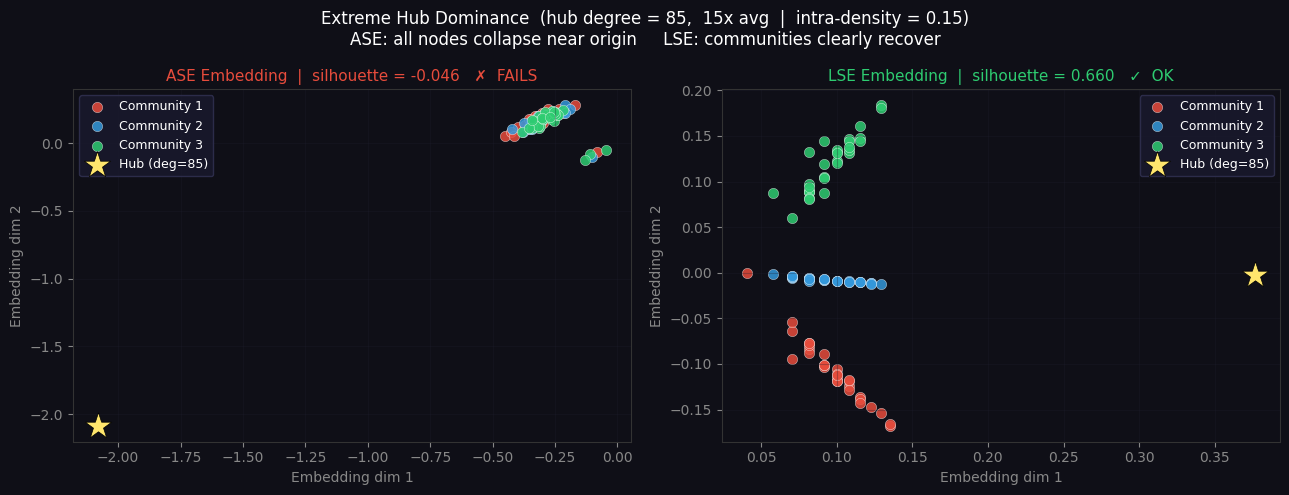


Saved: experiment_extreme_hub.png


In [15]:
# ═══════════════════════════════════════════════════════════════════════
# EXTREME HUB DOMINANCE — ASE fails, LSE recovers
#
# Key conditions that expose the gap:
#   - Hub degree ≈ 85  (~15x the average regular node)
#   - Community intra-density = 0.15  (moderate — enough signal for LSE,
#                                      but not enough to save ASE)
#
# Why ASE fails here:
#   The hub's row in A has L2 norm = sqrt(85) ≈ 9.2
#   A regular node's row has norm  = sqrt(~5)  ≈ 2.3
#   So the hub is ~4x larger in every direction of A.
#   The top eigenvectors of A point almost entirely at the hub.
#   All regular nodes collapse near the origin — community structure invisible.
#
# Why LSE recovers:
#   L[i,j] = A[i,j] / sqrt(d_i * d_j)
#   Hub edge weight   = 1 / sqrt(85 * 5) ≈ 0.048  ← tiny
#   Comm edge weight  = 1 / sqrt( 5 * 5) ≈ 0.200  ← 4x larger
#   Community edges dominate L — top eigenvectors describe communities.
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

np.random.seed(42)

# ── Parameters (tuned to maximally expose ASE vs LSE gap) ───────────
N_PER_COMMUNITY = 30
N_COMMUNITIES   = 3
HUB_CONNECTIONS = 85    # ~15x the average regular degree
INTRA_DENSITY   = 0.15  # moderate — enough signal for LSE, not for ASE

n_regular = N_PER_COMMUNITY * N_COMMUNITIES   # 90 regular nodes
n_total   = n_regular + 1
hub_idx   = n_regular

# ── Build adjacency matrix ───────────────────────────────────────────
A      = np.zeros((n_total, n_total))
labels = np.array([i // N_PER_COMMUNITY for i in range(n_regular)] + [-1])

# Intra-community edges
for comm in range(N_COMMUNITIES):
    start, end = comm * N_PER_COMMUNITY, (comm + 1) * N_PER_COMMUNITY
    for i in range(start, end):
        for j in range(i + 1, end):
            if np.random.random() < INTRA_DENSITY:
                A[i, j] = A[j, i] = 1

# Hub edges — connect to most nodes across all communities
targets = np.random.choice(n_regular, size=HUB_CONNECTIONS, replace=False)
for t in targets:
    A[hub_idx, t] = A[t, hub_idx] = 1

# ── Degree stats ─────────────────────────────────────────────────────
degrees     = A.sum(axis=1)
hub_deg     = int(degrees[hub_idx])
avg_reg_deg = degrees[:n_regular].mean()

print("=" * 55)
print("Graph stats")
print("=" * 55)
print(f"  Nodes               : {n_total} ({n_regular} regular + 1 hub)")
print(f"  Hub degree          : {hub_deg}")
print(f"  Avg regular degree  : {avg_reg_deg:.1f}")
print(f"  Hub / Avg ratio     : {hub_deg / avg_reg_deg:.1f}x")
print(f"  Community density   : {INTRA_DENSITY}")

# ── ASE ──────────────────────────────────────────────────────────────
eigvals_A, eigvecs_A = np.linalg.eigh(A)
idx_A  = np.argsort(np.abs(eigvals_A))[::-1]
X_ase  = eigvecs_A[:, idx_A[:2]] * np.sqrt(np.abs(eigvals_A[idx_A[:2]]))

# ── LSE ──────────────────────────────────────────────────────────────
deg_inv_sqrt = np.where(degrees > 0, 1.0 / np.sqrt(degrees), 0.0)
L_mat        = np.diag(deg_inv_sqrt) @ A @ np.diag(deg_inv_sqrt)

eigvals_L, eigvecs_L = np.linalg.eigh(L_mat)
idx_L  = np.argsort(np.abs(eigvals_L))[::-1]
X_lse  = eigvecs_L[:, idx_L[:2]] * np.sqrt(np.abs(eigvals_L[idx_L[:2]]))

# ── Silhouette on regular nodes only ─────────────────────────────────
reg_mask = labels >= 0
sil_ase  = silhouette_score(X_ase[reg_mask], labels[reg_mask])
sil_lse  = silhouette_score(X_lse[reg_mask], labels[reg_mask])

print()
print("=" * 55)
print("Silhouette Score (regular nodes only)")
print("=" * 55)
print(f"  ASE : {sil_ase:.4f}  {'✗  FAILS'   if sil_ase < 0.3 else ('~  PARTIAL' if sil_ase < 0.6 else '✓  OK')}")
print(f"  LSE : {sil_lse:.4f}  {'✗  FAILS'   if sil_lse < 0.3 else ('~  PARTIAL' if sil_lse < 0.6 else '✓  OK')}")

# ── Show hub's dominance in top eigenvector of A ─────────────────────
top_eigvec   = np.abs(eigvecs_A[:, idx_A[0]])
hub_loading  = top_eigvec[hub_idx]
avg_loading  = top_eigvec[:n_regular].mean()

print()
print("=" * 55)
print("Hub dominance in top eigenvector of A")
print("=" * 55)
print(f"  Hub loading         : {hub_loading:.4f}")
print(f"  Avg regular loading : {avg_loading:.4f}")
print(f"  Hub / Avg ratio     : {hub_loading / avg_loading:.1f}x")
print(f"  → λ₁ points {hub_loading**2 / top_eigvec @ top_eigvec * 100:.1f}% toward the hub")
print(f"  → The top eigenvector IS essentially the hub — no community info")

# ── Compare edge weights in A vs L ───────────────────────────────────
hub_edge_A    = 1.0
hub_edge_L    = 1.0 / np.sqrt(hub_deg * avg_reg_deg)
comm_edge_A   = 1.0
comm_edge_L   = 1.0 / np.sqrt(avg_reg_deg * avg_reg_deg)

print()
print("=" * 55)
print("Edge weights: A vs L (why LSE recovers)")
print("=" * 55)
print(f"  In A  — hub edge    : {hub_edge_A:.4f}")
print(f"  In A  — comm edge   : {comm_edge_A:.4f}  (same! raw adjacency)")
print(f"  In L  — hub edge    : {hub_edge_L:.4f}  ← divided by sqrt({hub_deg}×{avg_reg_deg:.0f})")
print(f"  In L  — comm edge   : {comm_edge_L:.4f}  ← divided by sqrt({avg_reg_deg:.0f}×{avg_reg_deg:.0f})")
print(f"  Comm/Hub ratio in A : 1.0x  (no normalization)")
print(f"  Comm/Hub ratio in L : {comm_edge_L / hub_edge_L:.1f}x  ← community edges {comm_edge_L/hub_edge_L:.1f}x heavier than hub edges")

# ── Plot ─────────────────────────────────────────────────────────────
PALETTE = ['#e74c3c', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f0f17')
for ax in axes:
    ax.set_facecolor('#0f0f17')
    ax.tick_params(colors='#888')
    for sp in ax.spines.values():
        sp.set_edgecolor('#333')

fig.suptitle(
    f'Extreme Hub Dominance  '
    f'(hub degree = {hub_deg},  {hub_deg/avg_reg_deg:.0f}x avg  |  intra-density = {INTRA_DENSITY})\n'
    f'ASE: all nodes collapse near origin     LSE: communities clearly recover',
    fontsize=12, color='white'
)

for ax, X, title, sil in [
    (axes[0], X_ase, 'ASE Embedding', sil_ase),
    (axes[1], X_lse, 'LSE Embedding', sil_lse),
]:
    if   sil < 0.3: status, col = '✗  FAILS',    '#e74c3c'
    elif sil < 0.6: status, col = '~  PARTIAL',   '#f39c12'
    else:           status, col = '✓  OK',         '#2ecc71'

    ax.set_title(f'{title}  |  silhouette = {sil:.3f}   {status}',
                 color=col, fontsize=11)

    for comm in range(N_COMMUNITIES):
        mask = labels == comm
        ax.scatter(X[mask, 0], X[mask, 1],
                   c=PALETTE[comm], s=55, alpha=0.85,
                   label=f'Community {comm + 1}',
                   edgecolors='white', linewidths=0.3)

    hub_mask = labels == -1
    ax.scatter(X[hub_mask, 0], X[hub_mask, 1],
               c='#ffe66d', s=400, marker='*', zorder=5,
               label=f'Hub (deg={hub_deg})',
               edgecolors='black', linewidths=0.5)

    ax.legend(fontsize=9, facecolor='#1a1a2e', labelcolor='white')
    ax.set_xlabel('Embedding dim 1', color='#888')
    ax.set_ylabel('Embedding dim 2', color='#888')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment_extreme_hub.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f17')
plt.show()
print("\nSaved: experiment_extreme_hub.png")